In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

os.chdir('/content/drive/My Drive/statistics_project')

print("Current working directory:", os.getcwd())

Mounted at /content/drive
Current working directory: /content/drive/My Drive/statistics_project


In [2]:
import pandas as pd

#Load the dataset
df = pd.read_csv('corpus_features.csv')

# Descriptive Statistics

**MEASURES OF CENTRAL TENDENCY AND VARIABILITY**

- Central Tendency (Mean vs. Median)
    - Mean - the sum of all values divided by the total number of observations
    - Median - the exact middle value of an ordered dataset

- Variability (Standard Deviation and IQR)
    - Standard Deviation - measures how much the data spreads out around the mean
    - The Interquartile Range (IQR) - represents the distance between the 75th percentile ($Q_3$) and the 25th percentile ($Q_1$), effectively capturing the spread of the "middle 50%" of the data and ignoring extreme outliers

In [3]:
# 1. Define a custom function to calculate the Interquartile Range (IQR)
def calculate_iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

# 2. Group the data by the 'Domain' column ('notice' vs 'plain') and calculate the four required statistics for both features.
summary_stats = df.groupby('Domain')[['avg_sent_len', 'flesch_re']].agg(
    ['mean', 'median', 'std', calculate_iqr]
).round(2) #Rounding to 2 decimal places to make the table look clean for the report

# 3. Print the resulting tablec
print(summary_stats)

       avg_sent_len                            flesch_re               \
               mean median   std calculate_iqr      mean median   std   
Domain                                                                  
notice        25.01  24.56  4.95          3.64     34.52  32.59  7.30   
plain         16.03  16.14  1.76          2.25     50.61  49.71  7.38   

                      
       calculate_iqr  
Domain                
notice          8.22  
plain          12.80  


In [4]:
# Descriptive statistics table: mean, median, SD, IQR per domain

def calculate_iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

summary_stats = df.groupby('Domain')[['avg_sent_len', 'flesch_re']].agg(
    ['mean', 'median', 'std', calculate_iqr]
).round(2)

# rename the IQR column from 'calculate_iqr' to 'IQR' so the table reads cleanly
summary_stats = summary_stats.rename(columns={'calculate_iqr': 'IQR'})

print(summary_stats)

# save it so you can drop the numbers straight into your report with no retyping
summary_stats.to_csv('descriptive_stats.csv')

       avg_sent_len                    flesch_re                    
               mean median   std   IQR      mean median   std    IQR
Domain                                                              
notice        25.01  24.56  4.95  3.64     34.52  32.59  7.30   8.22
plain         16.03  16.14  1.76  2.25     50.61  49.71  7.38  12.80


# Data Visualization

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

#clean, academic style for the charts
sns.set_theme(style="whitegrid")


**Average Sentence Length (histogram)**

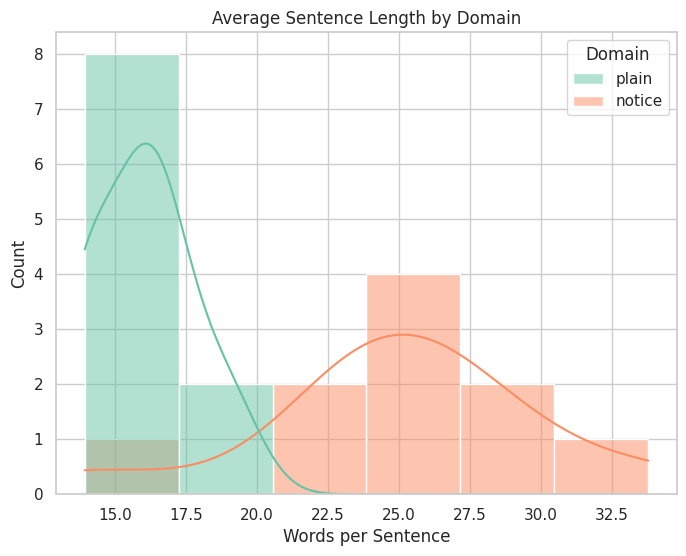

In [6]:
#Initialize a fresh figure canvas specifically for this chart.
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='avg_sent_len', hue='Domain', kde=True, palette="Set2")
plt.title('Average Sentence Length by Domain')
plt.xlabel('Words per Sentence')

#Save the file
#bbox_inches='tight' ensures the title and axis labels don't get cut off.
plt.savefig('histogram_sentence_length.png', dpi=300, bbox_inches='tight')
plt.show()

**Flesch Reading Ease (histogram)**

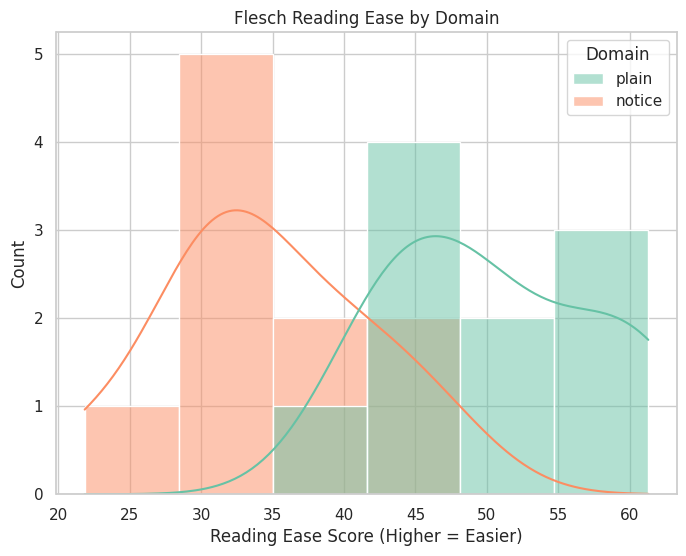

In [7]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='flesch_re', hue='Domain', kde=True, palette="Set2")
plt.title('Flesch Reading Ease by Domain')
plt.xlabel('Reading Ease Score (Higher = Easier)')

plt.savefig('histogram_flesch_reading_ease.png', dpi=300, bbox_inches='tight')
plt.show()

**Average Sentence Length (Boxplot)**

/tmp/ipykernel_15430/4120539878.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Domain', y='avg_sent_len', palette="Set2")


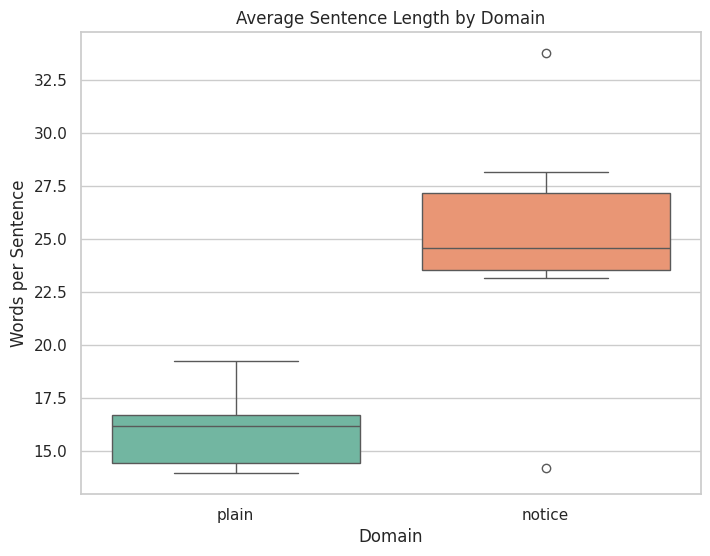

In [8]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Domain', y='avg_sent_len', palette="Set2")
plt.title('Average Sentence Length by Domain')
plt.ylabel('Words per Sentence')

plt.savefig('boxplot_sentence_length.png', dpi=300, bbox_inches='tight')
plt.show()

**Flesch Reading Ease (Boxplot)**

/tmp/ipykernel_15430/563978895.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Domain', y='flesch_re', palette="Set2")


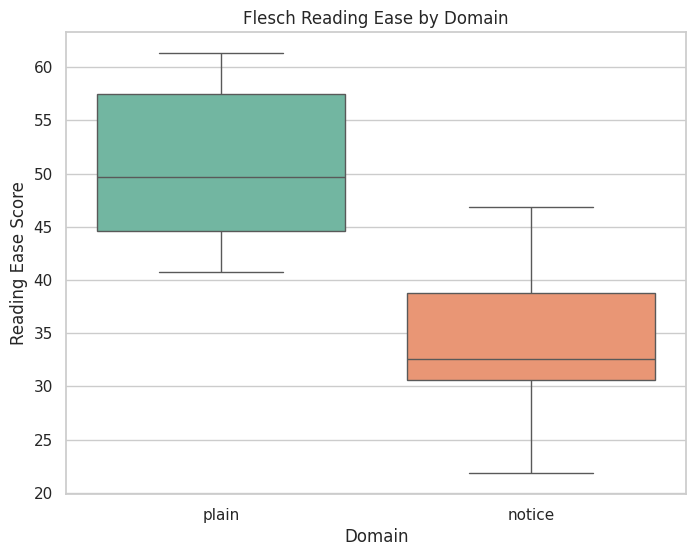

In [9]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Domain', y='flesch_re', palette="Set2")
plt.title('Flesch Reading Ease by Domain')
plt.ylabel('Reading Ease Score')

plt.savefig('boxplot_flesch_reading_ease.png', dpi=300, bbox_inches='tight')
plt.show()

# Inferential Statistics

**Confidence Intervals for Average Sentence Length**

In [10]:
import numpy as np
import scipy.stats as stats

#iterate through each unique domain category to calculate separate intervals for gov vs. corporate texts
print("95% Confidence Intervals for Average Sentence Length")

for doc_domain in df['Domain'].unique():
    #isolate the continuous variable (sentence length) for the specific group currently in the loop
    group_data = df[df['Domain'] == doc_domain]['avg_sent_len']

    #calculate the Standard Error of the Mean, which represents the standard deviation of the sampling distribution
    standard_error = stats.sem(group_data)

    #generate the interval bounds using the t-distribution. df is degrees of freedom (n-1)
    ci_lower, ci_upper = stats.t.interval(
        confidence=0.95,
        df=len(group_data) - 1,
        loc=np.mean(group_data),
        scale=standard_error
    )

    #output the final interval rounded to two decimal places
    print(f"{doc_domain.capitalize()} Texts: ({round(ci_lower, 2)} to {round(ci_upper, 2)}) words per sentence")

95% Confidence Intervals for Average Sentence Length
Plain Texts: (14.78 to 17.29) words per sentence
Notice Texts: (21.47 to 28.55) words per sentence
